# Assignment 2: CNN for Image Classification
## ICS3308 - Deep Learning

**Objective:** Apply a CNN to CIFAR-10 to demonstrate how convolutional networks learn image classification.

### Overview
- Loading CIFAR-10, data augmentation
- Building a CNN from scratch
- Training and evaluation
- Visualizing learned filters and feature maps

## 1. Install and Import Dependencies

In [15]:
!pip install torch torchvision scikit-learn matplotlib seaborn numpy

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Load and Explore CIFAR-10

CIFAR-10: 60,000 colour images (32×32) across 10 classes.

In [17]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

classes = ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f'Training: {len(train_dataset)} | Test: {len(test_dataset)} | Classes: {len(classes)}')

Training: 50000 | Test: 10000 | Classes: 10


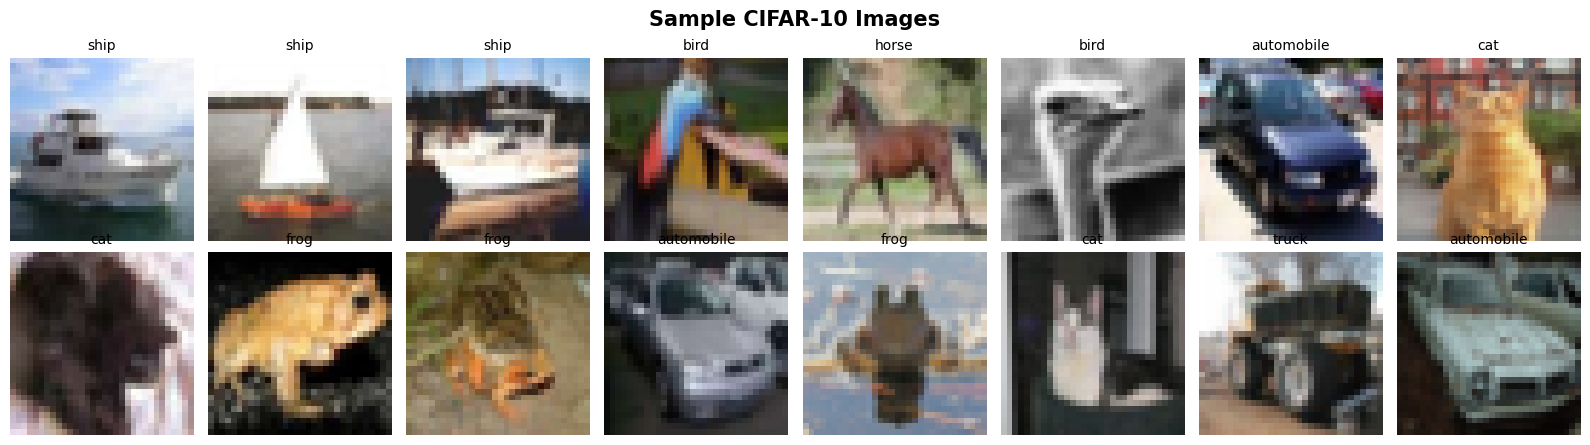

In [18]:
display_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False,
                                                transform=transforms.ToTensor())
fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
fig.suptitle('Sample CIFAR-10 Images', fontsize=15, fontweight='bold')
for i in range(16):
    idx = np.random.randint(len(display_dataset))
    img, label = display_dataset[idx]
    axes[i//8, i%8].imshow(img.permute(1,2,0).numpy())
    axes[i//8, i%8].set_title(classes[label], fontsize=10)
    axes[i//8, i%8].axis('off')
plt.tight_layout(); plt.show()

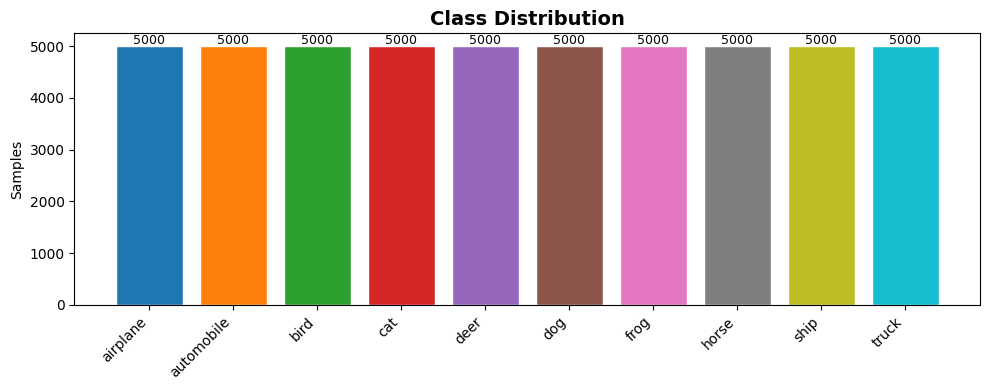

In [19]:
train_labels = [l for _, l in train_dataset]
unique, counts = np.unique(train_labels, return_counts=True)
plt.figure(figsize=(10, 4))
bars = plt.bar([classes[i] for i in unique], counts, color=plt.cm.tab10(np.linspace(0,1,10)), edgecolor='white')
plt.ylabel('Samples'); plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
for bar, c in zip(bars, counts):
    plt.text(bar.get_x()+bar.get_width()/2., bar.get_height()+50, str(c), ha='center', fontsize=9)
plt.tight_layout(); plt.show()

## 3. How CNNs Learn

A CNN learns through a hierarchy of convolutional filters:
1. **Early layers**: edges, corners, colours
2. **Middle layers**: textures, patterns, shapes
3. **Deep layers**: object parts, semantic concepts

Key operations: **Convolution** (detect local patterns), **Pooling** (spatial invariance), **FC layers** (final classification).

## 4. Define the CNN

In [20]:
class CIFAR10_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25))
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25))
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 512), nn.BatchNorm1d(512), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(512, 128), nn.BatchNorm1d(128), nn.ReLU(True), nn.Dropout(0.3),
            nn.Linear(128, num_classes))

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        return self.classifier(x)

model = CIFAR10_CNN().to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

CIFAR10_CNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2

## 5. Training

In [21]:
NUM_EPOCHS = 30
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)

train_losses, train_accs, test_losses, test_accs = [], [], [], []

for epoch in range(NUM_EPOCHS):
    model.train()
    rl, correct, total = 0., 0, 0
    for imgs, labs in train_loader:
        imgs, labs = imgs.to(device), labs.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labs)
        loss.backward(); optimizer.step()
        rl += loss.item()*imgs.size(0)
        correct += out.argmax(1).eq(labs).sum().item()
        total += labs.size(0)
    scheduler.step()
    train_losses.append(rl/total); train_accs.append(100.*correct/total)

    model.eval()
    rl, correct, total = 0., 0, 0
    with torch.no_grad():
        for imgs, labs in test_loader:
            imgs, labs = imgs.to(device), labs.to(device)
            out = model(imgs)
            rl += criterion(out, labs).item()*imgs.size(0)
            correct += out.argmax(1).eq(labs).sum().item()
            total += labs.size(0)
    test_losses.append(rl/total); test_accs.append(100.*correct/total)

    print(f'Epoch [{epoch+1:2d}/{NUM_EPOCHS}] '
          f'Train Loss: {train_losses[-1]:.4f} Acc: {train_accs[-1]:.2f}% | '
          f'Test Loss: {test_losses[-1]:.4f} Acc: {test_accs[-1]:.2f}%')

print(f'\nFinal Test Accuracy: {test_accs[-1]:.2f}%')

Epoch [ 1/30] Train Loss: 1.7369 Acc: 35.81% | Test Loss: 1.2635 Acc: 53.71%
Epoch [ 2/30] Train Loss: 1.3769 Acc: 50.19% | Test Loss: 1.0024 Acc: 63.86%
Epoch [ 3/30] Train Loss: 1.2012 Acc: 57.25% | Test Loss: 0.9078 Acc: 67.95%
Epoch [ 4/30] Train Loss: 1.0836 Acc: 62.01% | Test Loss: 0.8125 Acc: 71.27%
Epoch [ 5/30] Train Loss: 1.0087 Acc: 64.65% | Test Loss: 0.7482 Acc: 73.73%
Epoch [ 6/30] Train Loss: 0.9525 Acc: 66.94% | Test Loss: 0.7057 Acc: 74.97%
Epoch [ 7/30] Train Loss: 0.9105 Acc: 68.49% | Test Loss: 0.6661 Acc: 76.86%
Epoch [ 8/30] Train Loss: 0.8710 Acc: 70.14% | Test Loss: 0.6399 Acc: 77.88%
Epoch [ 9/30] Train Loss: 0.8416 Acc: 71.11% | Test Loss: 0.6119 Acc: 79.20%
Epoch [10/30] Train Loss: 0.8153 Acc: 72.08% | Test Loss: 0.6012 Acc: 79.16%
Epoch [11/30] Train Loss: 0.7871 Acc: 73.11% | Test Loss: 0.5883 Acc: 79.58%
Epoch [12/30] Train Loss: 0.7707 Acc: 73.64% | Test Loss: 0.5865 Acc: 79.58%
Epoch [13/30] Train Loss: 0.7509 Acc: 74.42% | Test Loss: 0.5577 Acc: 81.05%

## 6. Training Curves

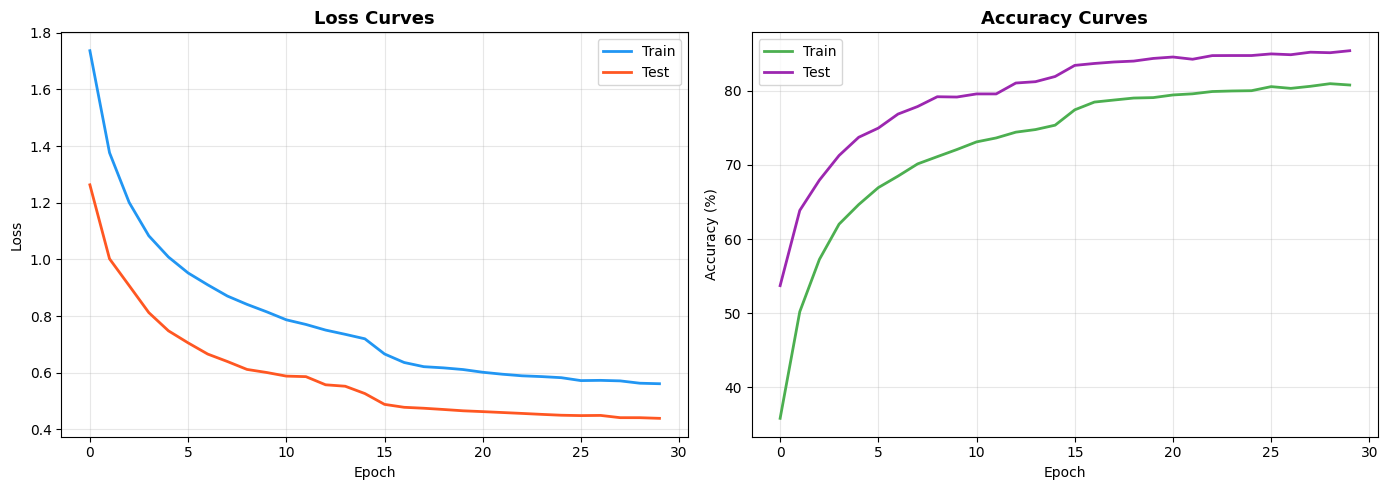

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses, label='Train', lw=2, color='#2196F3')
ax1.plot(test_losses, label='Test', lw=2, color='#FF5722')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves', fontsize=13, fontweight='bold')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, label='Train', lw=2, color='#4CAF50')
ax2.plot(test_accs, label='Test', lw=2, color='#9C27B0')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curves', fontsize=13, fontweight='bold')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Evaluation

In [23]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labs in test_loader:
        all_preds.extend(model(imgs.to(device)).argmax(1).cpu().numpy())
        all_labels.extend(labs.numpy())

print('Classification Report:')
print('='*60)
print(classification_report(all_labels, all_preds, target_names=classes, digits=3))

Classification Report:
              precision    recall  f1-score   support

    airplane      0.859     0.866     0.863      1000
  automobile      0.939     0.941     0.940      1000
        bird      0.849     0.744     0.793      1000
         cat      0.787     0.636     0.704      1000
        deer      0.825     0.871     0.847      1000
         dog      0.762     0.808     0.784      1000
        frog      0.852     0.904     0.877      1000
       horse      0.882     0.894     0.888      1000
        ship      0.904     0.930     0.917      1000
       truck      0.873     0.947     0.908      1000

    accuracy                          0.854     10000
   macro avg      0.853     0.854     0.852     10000
weighted avg      0.853     0.854     0.852     10000



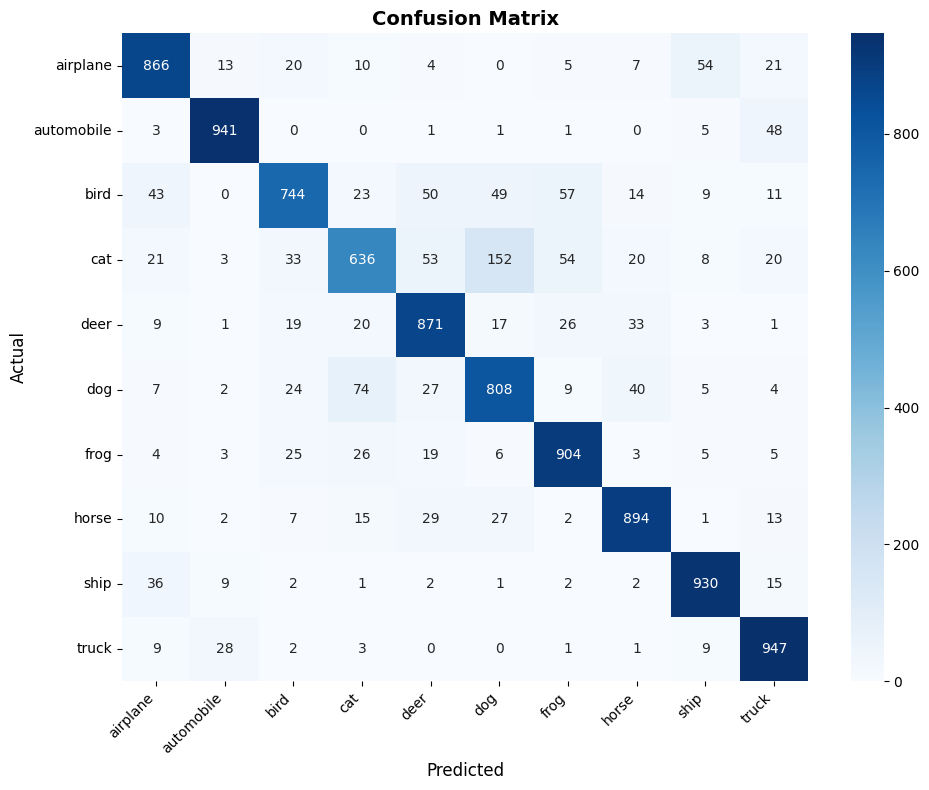

In [24]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted', fontsize=12); plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

### Interpreting the Confusion Matrix

The confusion matrix shows how often each class was predicted correctly (diagonal) vs. misclassified (off-diagonal).

**Strong performers** (high diagonal values):
- **automobile**, **truck**, **frog**, **ship** — distinctive shapes/contexts the CNN learns easily.

**Common confusions** (high off-diagonal values):
- **cat ↔ dog** — both are furry four-legged animals with similar textures.
- **bird ↔ frog/deer** — small animals on natural backgrounds share similar colour palettes.
- **automobile ↔ truck** — both are vehicles with similar overall structure.

**Key takeaway**: The CNN confuses classes that share visual features (shape, texture, colour). This is expected — even humans find tiny 32×32 cat/dog images ambiguous. Deeper architectures or higher-resolution inputs would reduce these errors.

## 8. Visualizing What the CNN Learns

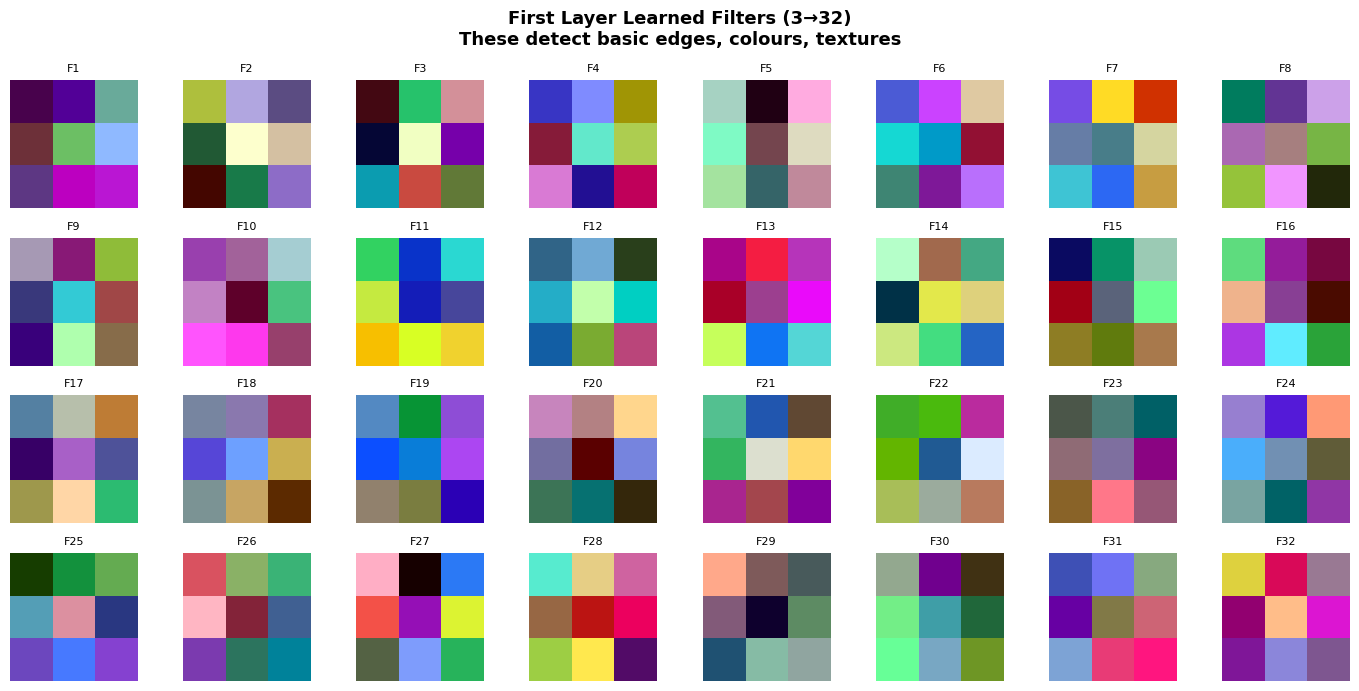

In [25]:
# First layer filters
filters = model.conv_block1[0].weight.data.cpu()
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
fig.suptitle('First Layer Learned Filters (3\u219232)\nThese detect basic edges, colours, textures',
             fontsize=13, fontweight='bold')
for i in range(32):
    ax = axes[i//8, i%8]
    f = filters[i]; f = (f - f.min()) / (f.max() - f.min() + 1e-8)
    ax.imshow(f.permute(1,2,0).numpy()); ax.set_title(f'F{i+1}', fontsize=8); ax.axis('off')
plt.tight_layout(); plt.show()

### Interpreting the First Layer Filters

These 32 tiny 3×3 patches are the **actual learned weights** of the first convolutional layer. Each filter slides across the input image looking for a specific local pattern.

**What the colours mean:** Each filter has 3 channels (R, G, B) — the colour of each pixel shows which colour combination the filter responds to. For example:
- A filter with a bright left half and dark right half detects **vertical edges**
- A filter with contrasting top/bottom detects **horizontal edges**
- A uniformly coloured filter responds to that **specific colour** in the image

**What to notice:**
- The filters show a variety of colour contrasts — the network has learned to detect different edge orientations and colour boundaries
- Some filters (e.g., F5, F21) have smooth, uniform colours — these act as **colour detectors**
- Others (e.g., F3, F13) have sharp colour transitions — these act as **edge detectors**
- No two filters are identical — the network avoids redundancy by learning diverse features

**Key insight:** These simple 3×3 patterns are the building blocks of everything the CNN recognises. Higher layers combine these basic edge/colour responses into increasingly complex features (textures → shapes → objects).

True: cat | Predicted: cat


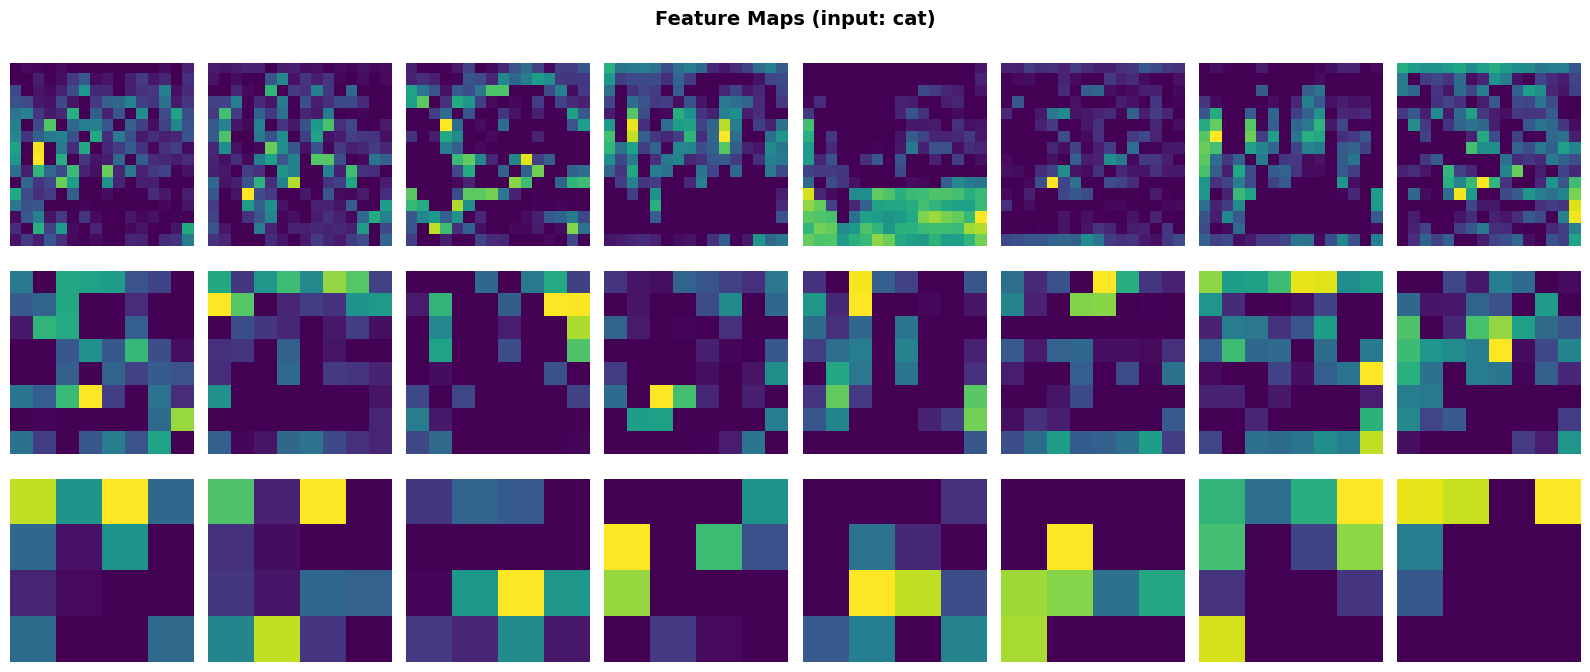

In [26]:
# Feature maps at each block
sample_img, sample_label = test_dataset[0]
activations = {}
def get_activation(name):
    def hook(m, i, o): activations[name] = o.detach().cpu()
    return hook

model.conv_block1.register_forward_hook(get_activation('conv1'))
model.conv_block2.register_forward_hook(get_activation('conv2'))
model.conv_block3.register_forward_hook(get_activation('conv3'))

model.eval()
with torch.no_grad():
    pred = classes[model(sample_img.unsqueeze(0).to(device)).argmax(1).item()]
print(f'True: {classes[sample_label]} | Predicted: {pred}')

fig, axes = plt.subplots(3, 8, figsize=(16, 7))
fig.suptitle(f'Feature Maps (input: {classes[sample_label]})', fontsize=14, fontweight='bold')
titles = ['Block 1 (edges)', 'Block 2 (textures)', 'Block 3 (parts)']
for row, (name, title) in enumerate(zip(['conv1','conv2','conv3'], titles)):
    act = activations[name][0]
    for col in range(8):
        axes[row, col].imshow(act[col].numpy(), cmap='viridis')
        axes[row, col].axis('off')
        if col == 0: axes[row, col].set_ylabel(title, fontsize=9, rotation=0, labelpad=100, va='center')
plt.tight_layout(); plt.show()

### Interpreting the Feature Maps

Each image above shows what a single convolutional filter "sees" when the cat image passes through it. Bright (yellow/green) regions indicate where the filter detected a strong match.

**Row 1 — Block 1 (16×16):** The maps are still spatially detailed — you can roughly make out the cat's outline. These filters detect **low-level features** like edges, colour boundaries, and simple textures. Each filter responds to a different pattern (e.g., horizontal edges vs. vertical edges).

**Row 2 — Block 2 (8×8):** Spatial resolution is halved after pooling. The maps are more abstract — individual pixels no longer correspond to recognisable parts. These filters combine edges into **mid-level features** like fur texture, ear shapes, or background patterns.

**Row 3 — Block 3 (4×4):** Very low resolution, very abstract. Each "pixel" now summarises a large region of the original image. These filters encode **high-level semantic concepts** — essentially asking "does this region look like part of a cat?" rather than detecting specific edges.

**Key insight:** As we go deeper, the CNN trades **spatial detail** for **semantic understanding**. The final 4×4 maps are what the fully connected classifier uses to decide "cat" vs. other classes.

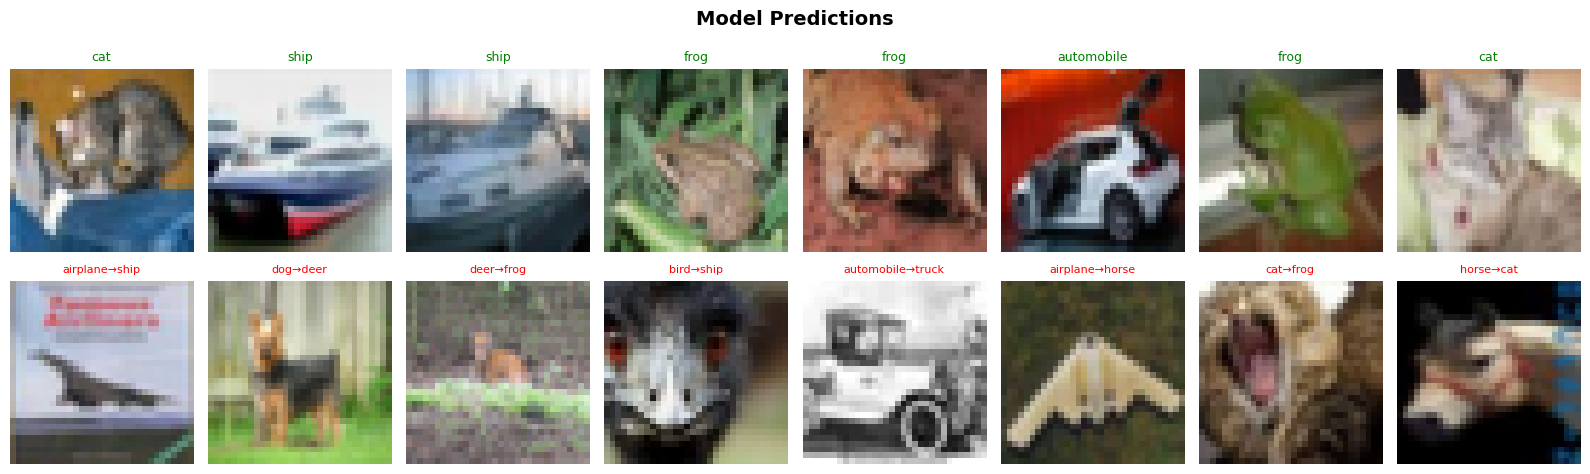

In [27]:
# Correct vs incorrect predictions
model.eval()
correct_s, incorrect_s = [], []
with torch.no_grad():
    for imgs, labs in test_loader:
        preds = model(imgs.to(device)).argmax(1)
        for i in range(len(labs)):
            if preds[i].item() == labs[i].item() and len(correct_s) < 8:
                correct_s.append((imgs[i].cpu(), labs[i].item(), preds[i].item()))
            elif preds[i].item() != labs[i].item() and len(incorrect_s) < 8:
                incorrect_s.append((imgs[i].cpu(), labs[i].item(), preds[i].item()))
        if len(correct_s) >= 8 and len(incorrect_s) >= 8: break

mean = torch.tensor([0.4914,0.4822,0.4465]).view(3,1,1)
std = torch.tensor([0.2470,0.2435,0.2616]).view(3,1,1)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Model Predictions', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Correct \u2713', fontsize=12, color='green', fontweight='bold')
axes[1,0].set_ylabel('Wrong \u2717', fontsize=12, color='red', fontweight='bold')
for i,(img,t,p) in enumerate(correct_s[:8]):
    img = (img*std+mean).clamp(0,1)
    axes[0,i].imshow(img.permute(1,2,0).numpy()); axes[0,i].set_title(classes[p], fontsize=9, color='green'); axes[0,i].axis('off')
for i,(img,t,p) in enumerate(incorrect_s[:8]):
    img = (img*std+mean).clamp(0,1)
    axes[1,i].imshow(img.permute(1,2,0).numpy()); axes[1,i].set_title(f'{classes[t]}\u2192{classes[p]}', fontsize=8, color='red'); axes[1,i].axis('off')
plt.tight_layout(); plt.show()

## 9. Conclusion

### How the CNN Learns
1. **Conv layers** extract hierarchical features: edges → textures → object parts
2. **Pooling** provides spatial invariance
3. **FC layers** combine features for classification

### Key Observations
- Data augmentation significantly improves generalisation
- The CNN most often confuses visually similar classes (cat/dog, auto/truck)
- Feature maps confirm deeper layers capture more abstract, class-discriminative features

### CNN vs MLP
- CNNs share weights across spatial locations (parameter efficient)
- They exploit image spatial structure — nearby pixels are more related than distant ones
- This makes CNNs the architecture of choice for computer vision